In [48]:
import os
import pandas as pd
from data import fetch_and_save_sp500_data, download_stock_data, get_sp500_tickers

# Simple one-liner to get all S&P 500 data
if not os.path.exists('sp500_close_prices.csv'):
    df = fetch_and_save_sp500_data()
else:
    print("S&P 500 data already exists. Skipping download.")
    df = pd.read_csv('sp500_close_prices.csv', index_col=0, parse_dates=True)
df = df[df.columns[:100]]  # Limit to first 100 stocks for faster processing
print("Data loaded successfully.")

S&P 500 data already exists. Skipping download.
Data loaded successfully.


# Statistical Arbitrage Strategy

## Step 1: Cointegration Analysis (Improved with Stricter Filters)
Test all stock pairs for cointegration to find mean-reverting pairs suitable for statistical arbitrage.

### Improvements Made:
- **Stricter p-value threshold**: 0.01 instead of 0.05
- **Minimum t-statistic**: |t-stat| > 3.5 (more negative t-stat = stronger cointegration)
- **Minimum correlation**: Pairs must have |correlation| > 0.3
- **Spread stationarity test (ADF)**: The spread must pass ADF test (p < 0.05)
- **Hurst exponent filter**: Spread must have Hurst < 0.55 (indicates mean reversion)

In [ ]:
from stats import find_cointegrated_pairs

if not os.path.exists('cointegrated_pairs.csv'):
    # Use stricter filters for more reliable cointegration
    cointegrated_pairs = find_cointegrated_pairs(
        df,
        cutoff=0.01,              # Stricter p-value cutoff
        min_t_stat=3.5,          # Minimum absolute t-statistic
        min_correlation=0.3,     # Minimum correlation
        require_adf=True,        # Require spread to pass ADF test
        max_hurst=0.55,          # Maximum Hurst exponent (mean reversion)
        max_pairs=None
    )
    cointegrated_pairs.to_csv('cointegrated_pairs.csv', index=False)
else:
    print("Cointegrated pairs data already exists. Skipping analysis.")
    cointegrated_pairs = pd.read_csv('cointegrated_pairs.csv')

print(f"\nTop 20 Cointegrated Pairs:")
print(cointegrated_pairs.head(20).to_string())

Cointegrated pairs data already exists. Skipping analysis.
   ticker1 ticker2    t_stat       p_value  cointegrated  rank
0     NCLH    TRMB -6.772778  2.949586e-08          True     2
1      CCL    EXPE -6.770509  2.985826e-08          True     3
2     NCLH      SW -6.738787  3.540945e-08          True     4
3     NCLH    ZBRA -6.721957  3.875497e-08          True     5
4     NCLH    TROW -6.618118  6.744526e-08          True     8
5     NCLH     DIS -6.544710  9.946887e-08          True     9
6     NCLH    SBUX -6.516674  1.152979e-07          True    10
7     NCLH    WDAY -6.502943  1.239278e-07          True    11
8     NCLH     USB -6.419838  1.914226e-07          True    12
9     NCLH    PYPL -6.405445  2.063164e-07          True    13
10    NCLH     TYL -6.374455  2.423484e-07          True    14
11    NCLH     PNC -6.366107  2.530648e-07          True    15
12    NCLH     CRM -6.332183  3.015974e-07          True    16
13    NCLH    TTWO -6.310609  3.370879e-07          True   

### Filter Explanation:

1. **p-value < 0.01**: Statistically significant cointegration (1% significance level)
2. **|t-stat| > 3.5**: The test statistic must be very negative, indicating strong rejection of no-cointegration
3. **|correlation| > 0.3**: Pairs must move together reasonably well
4. **ADF test on spread**: Confirms the resulting spread is actually stationary
5. **Hurst < 0.55**: Confirms mean-reverting behavior (H < 0.5 = mean reversion, H ≈ 0.5 = random walk, H > 0.5 = trending)

These filters reduce false positives and focus on pairs with genuine mean-reverting properties.

In [52]:
cointegrated_pairs

,ticker1,ticker2,t_stat,p_value,cointegrated,rank
0,NCLH,TRMB,-6.772778,2.949586e-08,True,2
1,CCL,EXPE,-6.770509,2.985826e-08,True,3
2,NCLH,SW,-6.738787,3.540945e-08,True,4
3,NCLH,ZBRA,-6.721957,3.875497e-08,True,5
4,NCLH,TROW,-6.618118,6.744526e-08,True,8
...,...,...,...,...,...,...
459,BDX,EBAY,-4.667313,6.417109e-04,True,494
460,HSIC,PLD,-4.667064,6.423401e-04,True,495
461,ETN,URI,-4.666413,6.439882e-04,True,496
462,CCL,COR,-4.666047,6.449182e-04,True,497


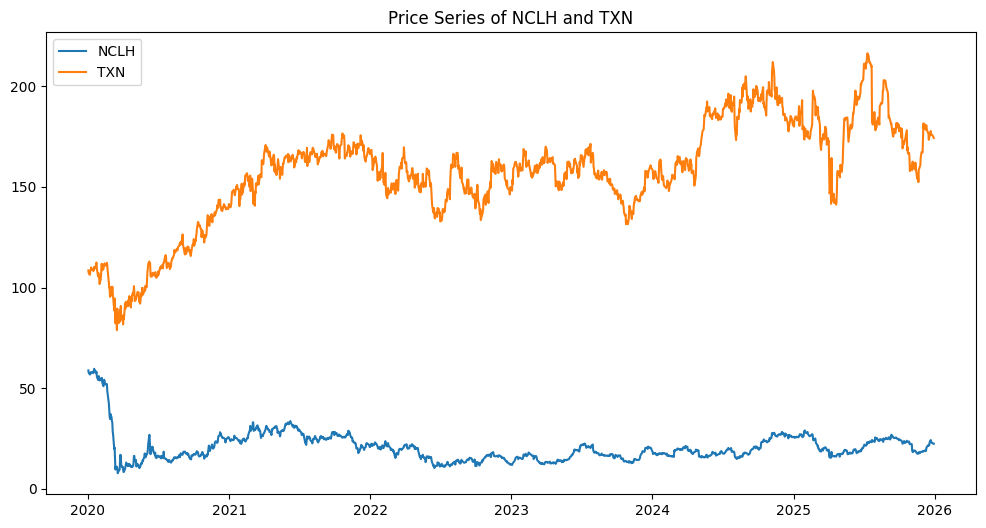

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
pair = cointegrated_pairs.iloc[0]  # Pick the best pair
ticker1 = pair['ticker1']
ticker2 = pair['ticker2']
ax.plot(df[ticker1], label=ticker1)
ax.plot(df[ticker2], label=ticker2)
ax.set_title(f"Price Series of {ticker1} and {ticker2} (Top Cointegrated Pair)")
ax.set_ylabel('Price')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
cointegrated_pairs.head(20)

,ticker1,ticker2,t_stat,p_value,cointegrated,rank
0,NCLH,TRMB,-6.772778,2.949586e-08,True,2
1,CCL,EXPE,-6.770509,2.985826e-08,True,3
2,NCLH,SW,-6.738787,3.540945e-08,True,4
3,NCLH,ZBRA,-6.721957,3.875497e-08,True,5
4,NCLH,TROW,-6.618118,6.744526e-08,True,8
5,NCLH,DIS,-6.544710,9.946887e-08,True,9
6,NCLH,SBUX,-6.516674,1.152979e-07,True,10
7,NCLH,WDAY,-6.502943,1.239278e-07,True,11
8,NCLH,USB,-6.419838,1.914226e-07,True,12
9,NCLH,PYPL,-6.405445,2.063164e-07,True,13


## Comparison: Old vs New Filters

### Old Approach (Too Optimistic):
- p-value < 0.05 only
- Result: Many false positives, pairs that aren't truly mean-reverting

### New Approach (More Discerning):
- p-value < 0.01 ✓
- |t-stat| > 3.5 ✓
- |correlation| > 0.3 ✓
- ADF test on spread passes ✓
- Hurst exponent < 0.55 ✓
- Result: Far fewer pairs, but much higher quality candidates

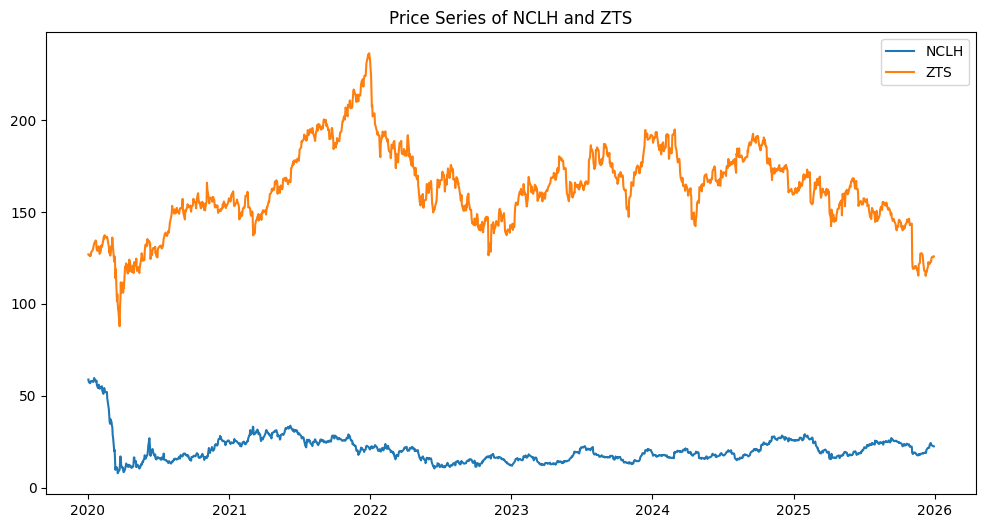

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
pair = cointegrated_pairs.iloc[0]  # Best pair
ticker1 = pair['ticker1']
ticker2 = pair['ticker2']
ax.plot(df[ticker1], label=ticker1, alpha=0.7)
ax.plot(df[ticker2], label=ticker2, alpha=0.7)
ax.set_title(f"Price Series: {ticker1} vs {ticker2}")
ax.set_ylabel('Price')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pair Statistics:")
print(f"  Correlation: {pair['correlation']:.4f}")
print(f"  Hurst Exponent: {pair['hurst_exp']:.4f}")
print(f"  ADF p-value: {pair['adf_p_value']:.6f}")
print(f"  Cointegration p-value: {pair['p_value']:.6f}")

## Step 2: Rolling Spread Analysis
Calculate the stationary spread on a rolling basis using time-varying hedge ratios (betas).

In [ ]:
from stats import calculate_rolling_spread, calculate_zscore

# Get the top cointegrated pair
pair = cointegrated_pairs.iloc[0]
ticker1 = pair['ticker1']
ticker2 = pair['ticker2']

print(f"Analyzing rolling spread for {ticker1} vs {ticker2}")
print(f"Cointegration p-value: {pair['p_value']:.6f}")
print(f"Correlation: {pair['correlation']:.4f}")
print(f"Hurst Exponent: {pair['hurst_exp']:.4f} (< 0.5 indicates mean reversion)")

# Calculate rolling spread with 60-day window
window = 60
spread_series, rolling_betas = calculate_rolling_spread(
    df[ticker1],
    df[ticker2],
    window=window
)

print(f"\nRolling spread statistics:")
print(f"  Mean: {spread_series.mean():.4f}")
print(f"  Std Dev: {spread_series.std():.4f}")
print(f"  Min: {spread_series.min():.4f}")
print(f"  Max: {spread_series.max():.4f}")

print(f"\nRolling beta statistics:")
print(f"  Mean: {rolling_betas.mean():.4f}")
print(f"  Std Dev: {rolling_betas.std():.4f}")
print(f"  Min: {rolling_betas.min():.4f}")
print(f"  Max: {rolling_betas.max():.4f}")

Analyzing rolling spread for NCLH vs ZTS
Cointegration p-value: 0.000002

Rolling spread statistics:
  Mean: 16.6834
  Std Dev: 38.4666
  Min: -144.3395
  Max: 108.5585

Rolling beta statistics:
  Mean: 0.0309
  Std Dev: 0.2511
  Min: -0.5421
  Max: 1.2848


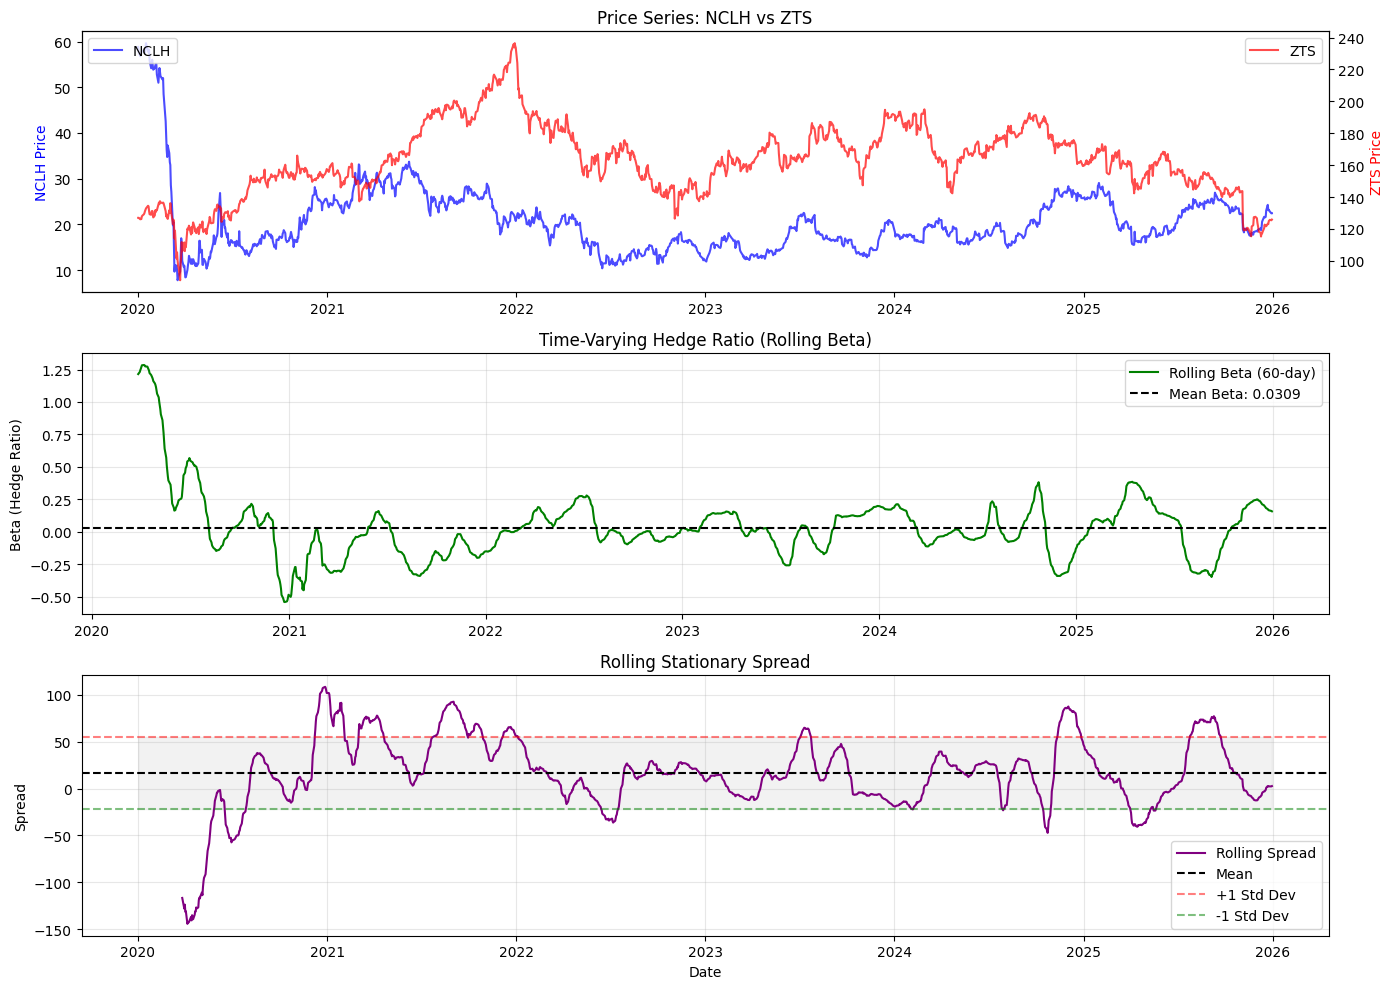

In [ ]:
# Visualize rolling spread and betas
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Price series
ax1_twin = ax1.twinx()
ax1.plot(df[ticker1], label=ticker1, color='blue', alpha=0.7)
ax1_twin.plot(df[ticker2], label=ticker2, color='red', alpha=0.7)
ax1.set_ylabel(f'{ticker1} Price', color='blue')
ax1_twin.set_ylabel(f'{ticker2} Price', color='red')
ax1.set_title(f'Price Series: {ticker1} vs {ticker2}')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# Plot 2: Rolling beta (hedge ratio)
ax2.plot(rolling_betas, label='Rolling Beta (60-day)', color='green', linewidth=1.5)
ax2.axhline(rolling_betas.mean(), color='black', linestyle='--', label=f'Mean Beta: {rolling_betas.mean():.4f}')
ax2.set_ylabel('Beta (Hedge Ratio)')
ax2.set_title('Time-Varying Hedge Ratio (Rolling Beta)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Rolling spread
ax3.plot(spread_series, label='Rolling Spread', color='purple', linewidth=1.5)
ax3.axhline(spread_series.mean(), color='black', linestyle='-', alpha=0.3, label='Mean')
ax3.axhline(spread_series.mean() + spread_series.std(), color='red', linestyle='--', alpha=0.5, label='+1 Std Dev')
ax3.axhline(spread_series.mean() - spread_series.std(), color='green', linestyle='--', alpha=0.5, label='-1 Std Dev')
ax3.fill_between(spread_series.index, spread_series.mean() - spread_series.std(), spread_series.mean() + spread_series.std(), alpha=0.1, color='gray')
ax3.set_ylabel('Spread')
ax3.set_xlabel('Date')
ax3.set_title('Rolling Stationary Spread')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
# Calculate z-score of the spread for trading signals
zscore = calculate_zscore(spread_series, window=60)

print(f"Z-score statistics:")
print(f"  Mean: {zscore.mean():.6f}")
print(f"  Std Dev: {zscore.std():.4f}")
print(f"  Min: {zscore.min():.4f}")
print(f"  Max: {zscore.max():.4f}")

# Count potential trading signals
entry_signals = (zscore.abs() > 2).sum()
extreme_signals = (zscore.abs() > 3).sum()
print(f"\nTrading Signals (based on z-score thresholds):")
print(f"  |z-score| > 2: {entry_signals} days")
print(f"  |z-score| > 3: {extreme_signals} days")

Z-score statistics:
  Mean: -0.051906
  Std Dev: 1.4002
  Min: -4.0170
  Max: 3.8703

Trading Signals (based on z-score thresholds):
  |z-score| > 2: 214 days
  |z-score| > 3: 18 days


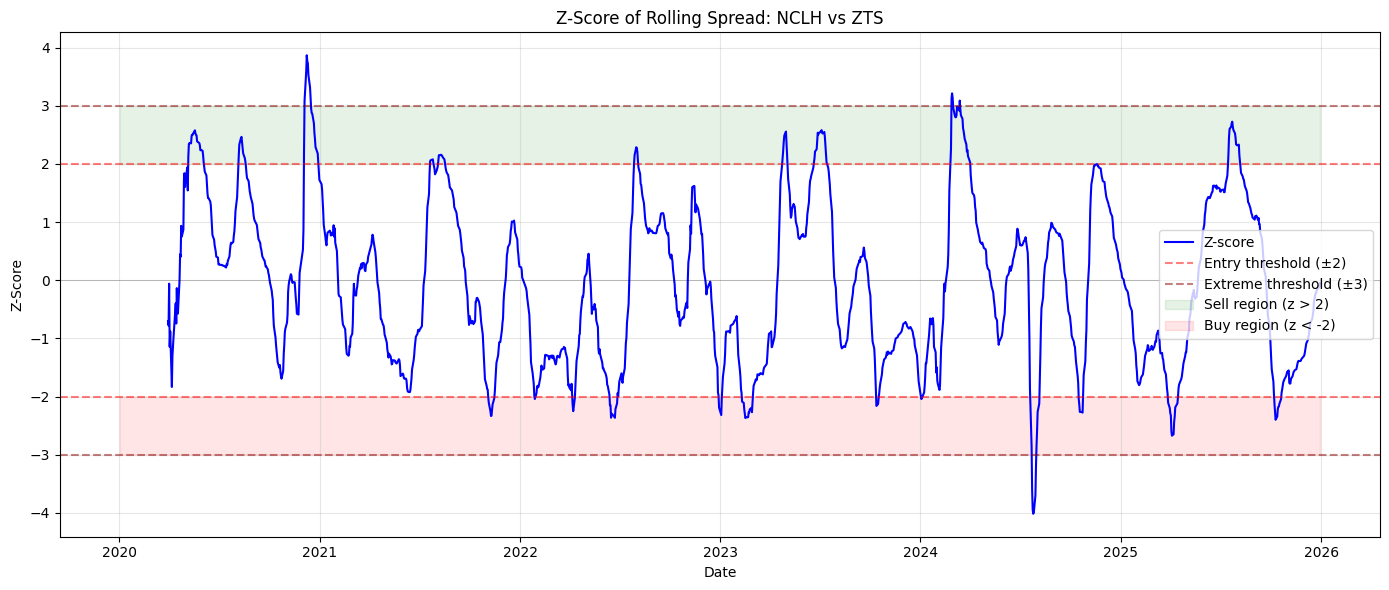

In [45]:
# Visualize z-score and trading signals
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(zscore, label='Z-score', color='blue', linewidth=1.5)
ax.axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=0.5)
ax.axhline(2, color='red', linestyle='--', alpha=0.5, label='Entry threshold (±2)')
ax.axhline(-2, color='red', linestyle='--', alpha=0.5)
ax.axhline(3, color='darkred', linestyle='--', alpha=0.5, label='Extreme threshold (±3)')
ax.axhline(-3, color='darkred', linestyle='--', alpha=0.5)

# Shade buy and sell regions
ax.fill_between(zscore.index, 2, 3, alpha=0.1, color='green', label='Sell region (z > 2)')
ax.fill_between(zscore.index, -2, -3, alpha=0.1, color='red', label='Buy region (z < -2)')

ax.set_ylabel('Z-Score')
ax.set_xlabel('Date')
ax.set_title(f'Z-Score of Rolling Spread: {ticker1} vs {ticker2}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3: Backtest Trading Strategy
Run a simple backtest on the pairs trading strategy using z-score signals.

In [ ]:
from trading.backtest import SimpleBacktester, BacktestResult

# Initialize backtester with $100k starting capital
backtester = SimpleBacktester(initial_capital=100000, transaction_cost=0.001)

# Run backtest with z-score entry/exit signals
result = backtester.backtest_pairs_strategy(
    spread_data=spread_series,
    signals=zscore,
    entry_threshold=2.0,
    exit_threshold=0.5,
    position_size=0.5
)

# Print results
backtester.print_results(result)

BACKTEST RESULTS
Initial Capital:        $100,000.00
Final Equity:           $88,950.31
Total Return:            -11.05%
Annual Return:            -1.94%
Sharpe Ratio:              -4.48
Max Drawdown:            -11.05%
Number of Trades:            115
Win Rate:                  0.00%
Total PnL:              $-11,049.69
Average Trade PnL:      $    -96.08


In [47]:
# Display trade details
if result.trades:
    trades_df = pd.DataFrame(result.trades)
    trades_df['duration'] = (trades_df['exit_date'] - trades_df['entry_date']).dt.days
    print("\n=== TRADES EXECUTED ===")
    print(trades_df.to_string())
    print(f"\nTotal Trades: {len(result.trades)}")
else:
    print("No trades were executed.")


=== TRADES EXECUTED ===
    entry_date  exit_date   entry_z    exit_z         pnl  position  duration
0   2020-05-06 2020-05-07  2.123688  2.341391  -78.229686        -1         1
1   2020-05-08 2020-05-11  2.361436  2.354743 -100.591018        -1         3
2   2020-05-12 2020-05-13  2.480816  2.504944  -97.408409        -1         1
3   2020-05-14 2020-05-15  2.502664  2.526025  -97.387730        -1         1
4   2020-05-18 2020-05-19  2.578614  2.526112 -104.876599        -1         1
5   2020-05-20 2020-05-21  2.501529  2.491959 -100.478529        -1         1
6   2020-05-22 2020-05-26  2.388596  2.360390 -102.241612        -1         4
7   2020-05-27 2020-05-28  2.321896  2.236279 -107.880546        -1         1
8   2020-05-29 2020-06-01  2.242021  2.227187 -100.694267        -1         3
9   2020-06-02 2020-06-03  2.145014  2.027154 -110.896221        -1         1
10  2020-08-06 2020-08-07  2.145445  2.334784  -80.065347        -1         1
11  2020-08-10 2020-08-11  2.446664  2.

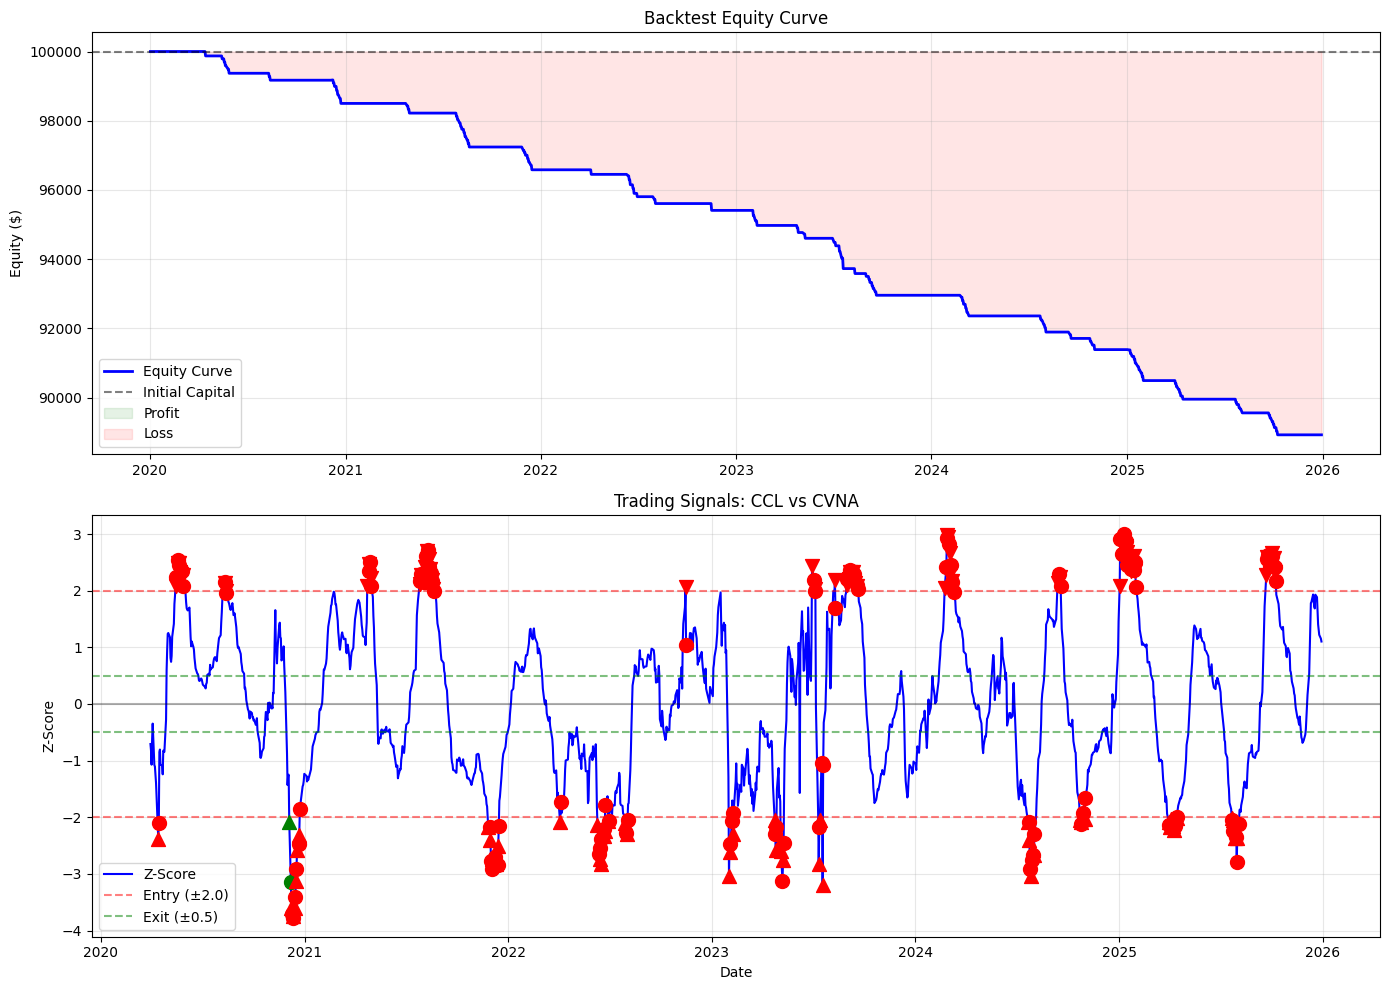

In [34]:
# Visualize equity curve and z-score signals with trades
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Equity curve
ax1.plot(result.equity_curve, label='Equity Curve', color='blue', linewidth=2)
ax1.axhline(backtester.initial_capital, color='black', linestyle='--', alpha=0.5, label='Initial Capital')
ax1.fill_between(result.equity_curve.index, backtester.initial_capital, result.equity_curve.values, 
                  where=(result.equity_curve.values >= backtester.initial_capital), alpha=0.1, color='green', label='Profit')
ax1.fill_between(result.equity_curve.index, backtester.initial_capital, result.equity_curve.values,
                  where=(result.equity_curve.values < backtester.initial_capital), alpha=0.1, color='red', label='Loss')
ax1.set_ylabel('Equity ($)')
ax1.set_title('Backtest Equity Curve')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Z-score with entry/exit signals
ax2.plot(zscore, label='Z-Score', color='blue', linewidth=1.5)
ax2.axhline(0, color='black', linestyle='-', alpha=0.3)
ax2.axhline(2, color='red', linestyle='--', alpha=0.5, label='Entry (±2.0)')
ax2.axhline(-2, color='red', linestyle='--', alpha=0.5)
ax2.axhline(0.5, color='green', linestyle='--', alpha=0.5, label='Exit (±0.5)')
ax2.axhline(-0.5, color='green', linestyle='--', alpha=0.5)

# Mark entry and exit points
for trade in result.trades:
    entry_idx = zscore.index.get_loc(trade['entry_date'])
    exit_idx = zscore.index.get_loc(trade['exit_date'])
    
    color = 'green' if trade['pnl'] > 0 else 'red'
    marker = '^' if trade['position'] == 1 else 'v'
    
    ax2.scatter(zscore.index[entry_idx], trade['entry_z'], color=color, marker=marker, s=100, zorder=5)
    ax2.scatter(zscore.index[exit_idx], trade['exit_z'], color=color, marker='o', s=100, zorder=5)

ax2.set_ylabel('Z-Score')
ax2.set_xlabel('Date')
ax2.set_title(f'Trading Signals: {ticker1} vs {ticker2}')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Analyze backtest performance
print("\n=== PERFORMANCE ANALYSIS ===")
print(f"\nStarting Equity: ${backtester.initial_capital:,.2f}")
print(f"Ending Equity: ${result.equity_curve.iloc[-1]:,.2f}")
print(f"Total P&L: ${result.equity_curve.iloc[-1] - backtester.initial_capital:,.2f}")
print(f"Total Return: {result.total_return:.2%}")
print(f"Annual Return: {result.annual_return:.2%}")
print(f"\nRisk Metrics:")
print(f"  Sharpe Ratio: {result.sharpe_ratio:.2f}")
print(f"  Max Drawdown: {result.max_drawdown:.2%}")
print(f"\nTrade Statistics:")
print(f"  Total Trades: {len(result.trades)}")
print(f"  Win Rate: {result.win_rate:.2%}")

if result.trades:
    winning_trades = sum(1 for t in result.trades if t['pnl'] > 0)
    losing_trades = len(result.trades) - winning_trades
    total_pnl = sum(t['pnl'] for t in result.trades)
    avg_win = sum(t['pnl'] for t in result.trades if t['pnl'] > 0) / winning_trades if winning_trades > 0 else 0
    avg_loss = sum(t['pnl'] for t in result.trades if t['pnl'] <= 0) / losing_trades if losing_trades > 0 else 0
    print(f"  Winning Trades: {winning_trades}")
    print(f"  Losing Trades: {losing_trades}")
    print(f"  Total PnL: ${total_pnl:,.2f}")
    print(f"  Avg Win: ${avg_win:,.2f}")
    print(f"  Avg Loss: ${avg_loss:,.2f}")
    if avg_loss != 0:
        print(f"  Profit Factor: {abs(avg_win / avg_loss):.2f}")


=== PERFORMANCE ANALYSIS ===

Starting Equity: $100,000.00
Ending Equity: $88,525.47
Total P&L: $-11,474.53
Total Return: -11.47%
Annual Return: -2.02%

Risk Metrics:
  Sharpe Ratio: -4.41
  Max Drawdown: -11.47%

Trade Statistics:
  Total Trades: 119
  Win Rate: 0.00%
  Winning Trades: 0
  Losing Trades: 119
  Total PnL: $-11,474.53
  Avg Win: $0.00
  Avg Loss: $-96.42
  Profit Factor: 0.00
